# Spectral Feature Evaluation for PyEO Forest Classification

**Author:** Satyam Shah  
**Date:** March 2026  
**Repository:** https://github.com/clcr/pyeo

## Background

The PyEO forest alert system uses a Random Forest classifier trained on four Sentinel-2
spectral bands: Blue (B02), Green (B03), Red (B04), and Near-Infrared (B08). The existing
model file is named `model_36MYE_Unoptimised_20230505_no_haze.pkl`, with the label
Unoptimised indicating that no systematic feature evaluation has been performed.

This notebook addresses that gap by evaluating whether adding derived vegetation indices
as additional input features improves classification accuracy across all six land cover
classes used in the Kenya forest alert system.

## Research Question

Do derived spectral indices (NDVI, NDWI, EVI) improve Random Forest classification
accuracy for PyEO land cover classes when added to the existing four-band feature set?

## Approach

Three models are trained and evaluated using stratified 80/20 train/test splits:

- Model A: Baseline (B02, B03, B04, B08) - replicates the existing PyEO model
- Model B: Baseline + NDVI + NDWI
- Model C: Baseline + NDVI + NDWI + EVI

All three models use identical Random Forest hyperparameters and the same train/test
split to ensure a fair comparison.

## Index Definitions

- NDVI (Normalised Difference Vegetation Index) = (B08 - B04) / (B08 + B04)
- NDWI (Normalised Difference Water Index) = (B03 - B08) / (B03 + B08)
- EVI (Enhanced Vegetation Index) = 2.5 * (B08 - B04) / (B08 + 6*B04 - 7.5*B02 + 1)

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)
import joblib
import os

print("Imports complete")

Imports complete


## 2. Configuration

Set the path to the training features CSV from the PyEO models directory.
Adjust `features_path` if your directory structure differs.

In [2]:
# Path to the existing PyEO training features CSV
# This file is produced by cls.extract_features_to_csv() in the model training notebook
features_path = "../models/my_model/my_model_features.csv"

# Output directory for saving results
output_dir = "./band_evaluation_results"
os.makedirs(output_dir, exist_ok=True)

# Class label mapping matching the PyEO Kenya classifier
CLASS_LABELS = {
    1:  "Primary Forest",
    2:  "Plantation Forest",
    3:  "Bare Soil",
    4:  "Crops",
    5:  "Grassland",
    13: "Artificial"
}

# Random seed for reproducibility
SEED = 42

print(f"Features path: {features_path}")
print(f"Output directory: {output_dir}")

Features path: ../models/my_model/my_model_features.csv
Output directory: ./band_evaluation_results


## 3. Load and Inspect Training Data

In [3]:
# Load the features CSV
# Column order: class, B02, B03, B04, B08 (no header in file)
df = pd.read_csv(features_path, header=None,
                 names=['class', 'B02', 'B03', 'B04', 'B08'])

# Convert class column to integer
df['class'] = df['class'].astype(int)

print(f"Total training pixels: {len(df)}")
print(f"\nClass distribution:")
for cls_id, count in df['class'].value_counts().sort_index().items():
    label = CLASS_LABELS.get(cls_id, f"Unknown ({cls_id})")
    pct = count / len(df) * 100
    print(f"  Class {cls_id:2d} ({label:<20s}): {count:5d} pixels ({pct:.1f}%)")

print(f"\nBand value ranges:")
for band in ['B02', 'B03', 'B04', 'B08']:
    print(f"  {band}: min={df[band].min():.0f}, max={df[band].max():.0f}, "
          f"mean={df[band].mean():.0f}")

Total training pixels: 11943

Class distribution:
  Class  1 (Primary Forest      ):  5910 pixels (49.5%)
  Class  2 (Plantation Forest   ):  1343 pixels (11.2%)
  Class  3 (Bare Soil           ):   616 pixels (5.2%)
  Class  4 (Crops               ):  1389 pixels (11.6%)
  Class  5 (Grassland           ):  1978 pixels (16.6%)
  Class 13 (Artificial          ):   707 pixels (5.9%)

Band value ranges:
  B02: min=100, max=4680, mean=335
  B03: min=171, max=4520, mean=537
  B04: min=115, max=4288, mean=406
  B08: min=1071, max=4473, mean=2875


## 4. Compute Spectral Indices

In [16]:
# Work with float copies to avoid integer division issues
B02 = df['B02'].values.astype(float)
B03 = df['B03'].values.astype(float)
B04 = df['B04'].values.astype(float)
B08 = df['B08'].values.astype(float)

# NDVI: Normalised Difference Vegetation Index
# Range: -1 to 1. High values indicate dense green vegetation.
ndvi_denom = B08 + B04
ndvi = np.where(ndvi_denom != 0, (B08 - B04) / ndvi_denom, 0.0)

# NDWI: Normalised Difference Water Index (Gao 1996)
# Range: -1 to 1. High values indicate water or high moisture content.
ndwi_denom = B03 + B08
ndwi = np.where(ndwi_denom != 0, (B03 - B08) / ndwi_denom, 0.0)

# EVI: Enhanced Vegetation Index
# More sensitive than NDVI in high-biomass regions, less affected by soil background.
B02n = B02 / 10000.0
B03n = B03 / 10000.0  
B04n = B04 / 10000.0
B08n = B08 / 10000.0

evi_denom = B08n + 6.0 * B04n - 7.5 * B02n + 1.0
evi = np.where(evi_denom != 0, 2.5 * (B08n - B04n) / evi_denom, 0.0)

# Add indices to dataframe
df['NDVI'] = ndvi
df['NDWI'] = ndwi
df['EVI']  = evi

print("Spectral indices computed:")
print(f"  NDVI: min={ndvi.min():.3f}, max={ndvi.max():.3f}, mean={ndvi.mean():.3f}")
print(f"  NDWI: min={ndwi.min():.3f}, max={ndwi.max():.3f}, mean={ndwi.mean():.3f}")
print(f"  EVI:  min={evi.min():.3f},  max={evi.max():.3f},  mean={evi.mean():.3f}")

Spectral indices computed:
  NDVI: min=-0.020, max=0.898, mean=0.775
  NDWI: min=-0.841, max=0.044, mean=-0.707
  EVI:  min=-0.088,  max=0.702,  mean=0.477


## 5. Visualise Index Distributions by Class

This plot shows how well each index separates the land cover classes.
Good separation means the index is likely to improve classification accuracy.

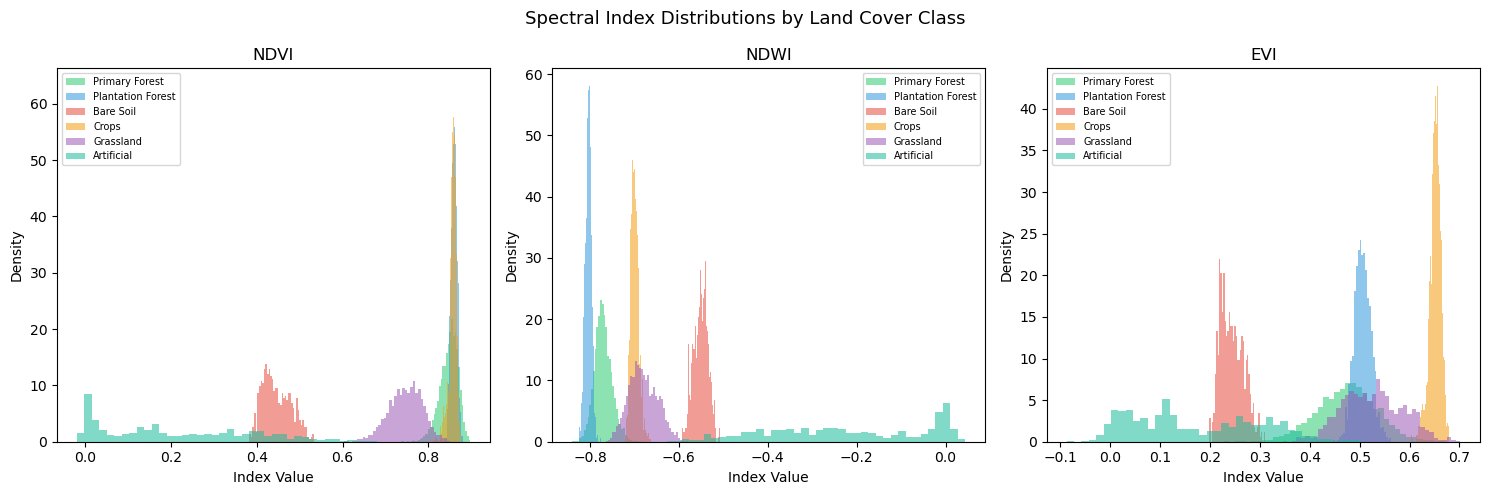

Figure saved to band_evaluation_results/index_distributions.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Spectral Index Distributions by Land Cover Class", fontsize=13)

indices   = ['NDVI', 'NDWI', 'EVI']
colors    = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

class_ids = sorted(df['class'].unique())

for ax, index in zip(axes, indices):
    for i, cls_id in enumerate(class_ids):
        subset = df[df['class'] == cls_id][index]
        label  = CLASS_LABELS.get(cls_id, str(cls_id))
        ax.hist(subset, bins=40, alpha=0.55, color=colors[i],
                label=label, density=True)
    ax.set_title(index)
    ax.set_xlabel("Index Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "index_distributions.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure saved to band_evaluation_results/index_distributions.png")

## 6. Build Feature Sets and Train/Test Split

In [18]:
y = df['class'].values

# Three feature sets for comparison
feature_sets = {
    "Model A: 4 Bands (Baseline)": df[['B02', 'B03', 'B04', 'B08']].values,
    "Model B: 4 Bands + NDVI + NDWI": df[['B02', 'B03', 'B04', 'B08',
                                           'NDVI', 'NDWI']].values,
    "Model C: 4 Bands + NDVI + NDWI + EVI": df[['B02', 'B03', 'B04', 'B08',
                                                  'NDVI', 'NDWI', 'EVI']].values
}

feature_names = {
    "Model A: 4 Bands (Baseline)": ['B02', 'B03', 'B04', 'B08'],
    "Model B: 4 Bands + NDVI + NDWI": ['B02', 'B03', 'B04', 'B08', 'NDVI', 'NDWI'],
    "Model C: 4 Bands + NDVI + NDWI + EVI": ['B02', 'B03', 'B04', 'B08',
                                               'NDVI', 'NDWI', 'EVI']
}

# Stratified 80/20 split - same split used for all three models
X_base = feature_sets["Model A: 4 Bands (Baseline)"]
X_train_idx, X_test_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training pixels : {len(X_train_idx)} ({len(X_train_idx)/len(y)*100:.0f}%)")
print(f"Test pixels     : {len(X_test_idx)} ({len(X_test_idx)/len(y)*100:.0f}%)")
print(f"\nTest set class distribution:")
y_test_check = y[X_test_idx]
for cls_id in sorted(np.unique(y_test_check)):
    label = CLASS_LABELS.get(cls_id, str(cls_id))
    count = np.sum(y_test_check == cls_id)
    print(f"  {label:<20s}: {count} pixels")

Training pixels : 9554 (80%)
Test pixels     : 2389 (20%)

Test set class distribution:
  Primary Forest      : 1182 pixels
  Plantation Forest   : 269 pixels
  Bare Soil           : 123 pixels
  Crops               : 278 pixels
  Grassland           : 396 pixels
  Artificial          : 141 pixels


## 7. Train and Evaluate All Three Models

In [19]:
# Random Forest hyperparameters match the PyEO default configuration
RF_PARAMS = dict(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

results     = {}
models      = {}
reports     = {}
cm_matrices = {}

for model_name, X in feature_sets.items():
    print(f"\nTraining {model_name}...")

    X_train = X[X_train_idx]
    X_test  = X[X_test_idx]
    y_train = y[X_train_idx]
    y_test  = y[X_test_idx]

    clf = RandomForestClassifier(**RF_PARAMS)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    overall_acc = accuracy_score(y_test, y_pred)
    macro_f1    = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')

    results[model_name] = {
        'overall_accuracy': overall_acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1
    }

    target_names = [CLASS_LABELS[c] for c in sorted(np.unique(y))]
    reports[model_name]     = classification_report(
        y_test, y_pred, target_names=target_names
    )
    cm_matrices[model_name] = confusion_matrix(y_test, y_pred,
                                               labels=sorted(np.unique(y)))
    models[model_name]      = clf

    print(f"  Overall Accuracy : {overall_acc:.4f}")
    print(f"  Macro F1         : {macro_f1:.4f}")
    print(f"  Weighted F1      : {weighted_f1:.4f}")

print("\nAll models trained.")


Training Model A: 4 Bands (Baseline)...
  Overall Accuracy : 0.9862
  Macro F1         : 0.9867
  Weighted F1      : 0.9861

Training Model B: 4 Bands + NDVI + NDWI...
  Overall Accuracy : 0.9853
  Macro F1         : 0.9860
  Weighted F1      : 0.9853

Training Model C: 4 Bands + NDVI + NDWI + EVI...
  Overall Accuracy : 0.9845
  Macro F1         : 0.9851
  Weighted F1      : 0.9844

All models trained.


## 8. Classification Reports

In [20]:
for model_name, report in reports.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(report)

    # Save to text file
    safe_name = model_name.split(":")[0].replace(" ", "_")
    report_path = os.path.join(output_dir, f"{safe_name}_class_scores.txt")
    with open(report_path, 'w') as f:
        f.write(f"{model_name}\n")
        f.write("=" * 60 + "\n")
        f.write(report)
    print(f"Saved to {report_path}")

Model A: 4 Bands (Baseline)
                   precision    recall  f1-score   support

   Primary Forest       0.98      0.99      0.99      1182
Plantation Forest       0.97      0.92      0.94       269
        Bare Soil       1.00      1.00      1.00       123
            Crops       1.00      0.99      1.00       278
        Grassland       0.99      1.00      0.99       396
       Artificial       1.00      0.99      1.00       141

         accuracy                           0.99      2389
        macro avg       0.99      0.98      0.99      2389
     weighted avg       0.99      0.99      0.99      2389

Saved to ./band_evaluation_results/Model_A_class_scores.txt
Model B: 4 Bands + NDVI + NDWI
                   precision    recall  f1-score   support

   Primary Forest       0.98      0.99      0.99      1182
Plantation Forest       0.95      0.93      0.94       269
        Bare Soil       1.00      1.00      1.00       123
            Crops       1.00      0.99      1.00   

## 9. Accuracy Comparison Summary

In [21]:
print(f"{'Model':<42} {'OA':>6} {'Macro F1':>10} {'Wt F1':>8}")
print("-" * 70)

baseline_oa = results["Model A: 4 Bands (Baseline)"]['overall_accuracy']
baseline_f1 = results["Model A: 4 Bands (Baseline)"]['macro_f1']

for model_name, res in results.items():
    oa   = res['overall_accuracy']
    mf1  = res['macro_f1']
    wf1  = res['weighted_f1']
    d_oa = oa - baseline_oa
    d_f1 = mf1 - baseline_f1
    delta = ""
    if model_name != "Model A: 4 Bands (Baseline)":
        delta = f"  (OA {d_oa:+.4f}, Macro F1 {d_f1:+.4f})"
    print(f"{model_name:<42} {oa:>6.4f} {mf1:>10.4f} {wf1:>8.4f}{delta}")

Model                                          OA   Macro F1    Wt F1
----------------------------------------------------------------------
Model A: 4 Bands (Baseline)                0.9862     0.9867   0.9861
Model B: 4 Bands + NDVI + NDWI             0.9853     0.9860   0.9853  (OA -0.0008, Macro F1 -0.0007)
Model C: 4 Bands + NDVI + NDWI + EVI       0.9845     0.9851   0.9844  (OA -0.0017, Macro F1 -0.0016)


## 10. Confusion Matrices

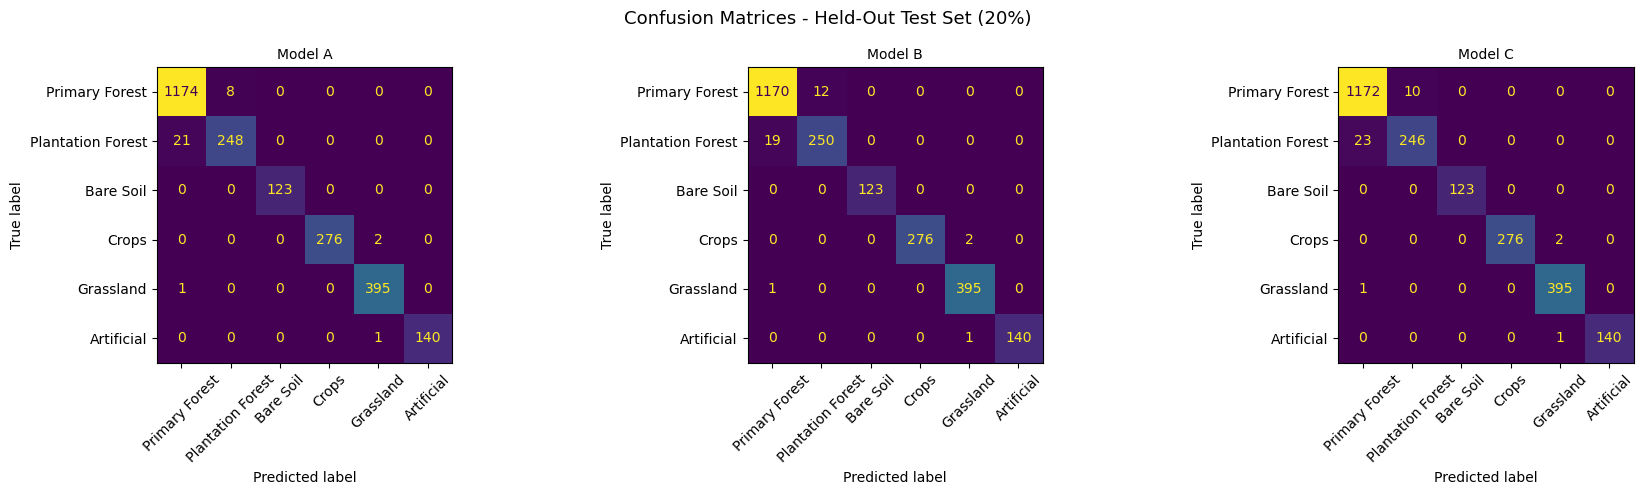

Figure saved to band_evaluation_results/confusion_matrices.png


In [22]:
class_labels_ordered = [CLASS_LABELS[c] for c in sorted(np.unique(y))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices - Held-Out Test Set (20%)", fontsize=13)

for ax, (model_name, cm) in zip(axes, cm_matrices.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_labels_ordered
    )
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    short_name = model_name.split(":")[0]
    ax.set_title(short_name, fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrices.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure saved to band_evaluation_results/confusion_matrices.png")

## 11. Feature Importance Analysis

Feature importances from the Random Forest show which inputs contribute
most to classification decisions. This is key to understanding whether
the added indices are genuinely informative or redundant.

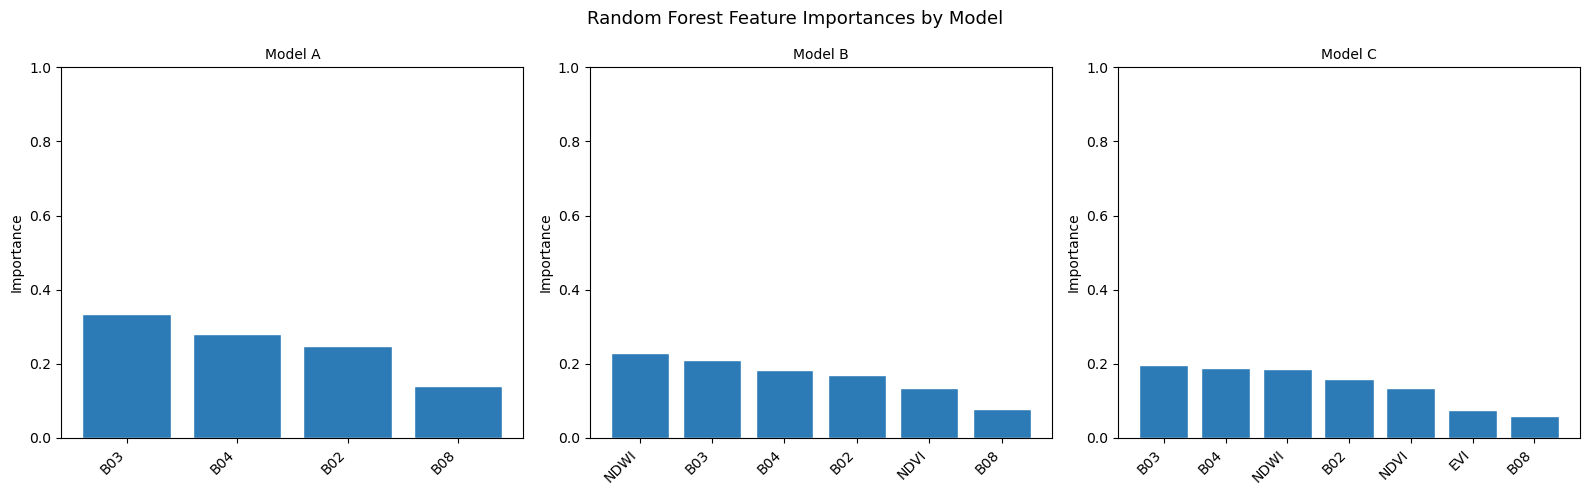

Figure saved to band_evaluation_results/feature_importances.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Random Forest Feature Importances by Model", fontsize=13)

bar_color = '#2c7bb6'

for ax, (model_name, clf) in zip(axes, models.items()):
    importances = clf.feature_importances_
    feat_names  = feature_names[model_name]
    sorted_idx  = np.argsort(importances)[::-1]

    ax.bar(
        range(len(importances)),
        importances[sorted_idx],
        color=bar_color,
        edgecolor='white'
    )
    ax.set_xticks(range(len(importances)))
    ax.set_xticklabels(
        [feat_names[i] for i in sorted_idx],
        rotation=45, ha='right'
    )
    short_name = model_name.split(":")[0]
    ax.set_title(short_name, fontsize=10)
    ax.set_ylabel("Importance")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "feature_importances.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure saved to band_evaluation_results/feature_importances.png")

## 12. Per-Class F1 Score Comparison

Overall accuracy can mask poor performance on minority classes.
This plot shows F1 score per class for all three models side by side.

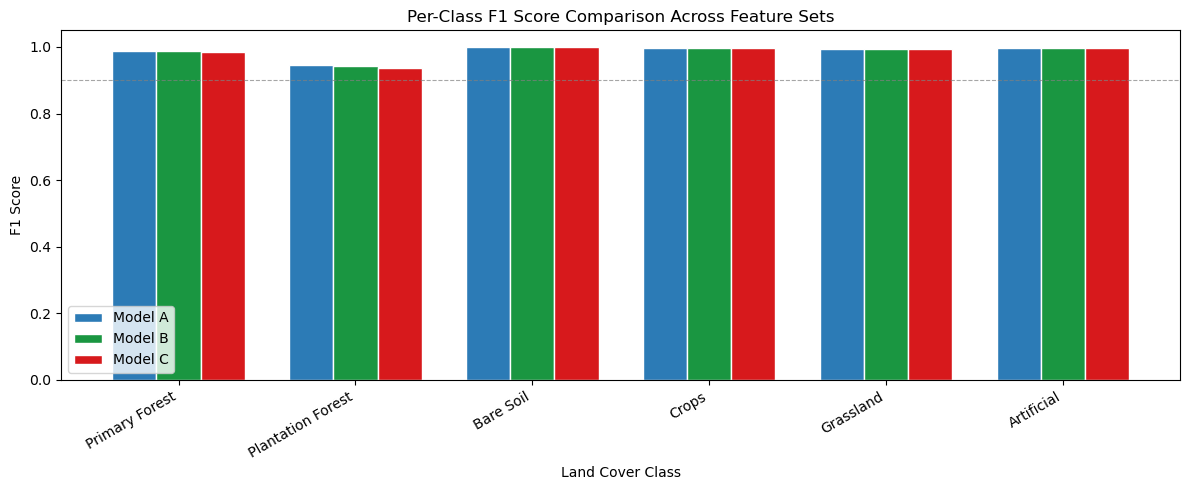

Figure saved to band_evaluation_results/per_class_f1.png


In [24]:
from sklearn.metrics import f1_score as f1_per_class

class_ids_sorted = sorted(np.unique(y))
class_names      = [CLASS_LABELS[c] for c in class_ids_sorted]
n_classes        = len(class_ids_sorted)

model_f1s  = {}
bar_colors = ['#2c7bb6', '#1a9641', '#d7191c']

for model_name, clf in models.items():
    X     = feature_sets[model_name]
    X_test = X[X_test_idx]
    y_test = y[X_test_idx]
    y_pred = clf.predict(X_test)
    f1s = f1_per_class(y_test, y_pred, labels=class_ids_sorted, average=None)
    model_f1s[model_name] = f1s

x      = np.arange(n_classes)
width  = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

for i, (model_name, f1s) in enumerate(model_f1s.items()):
    short = model_name.split(":")[0]
    ax.bar(x + i * width, f1s, width, label=short, color=bar_colors[i],
           edgecolor='white')

ax.set_xlabel("Land Cover Class")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score Comparison Across Feature Sets")
ax.set_xticks(x + width)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "per_class_f1.png"), dpi=150,
            bbox_inches='tight')
plt.show()
print("Figure saved to band_evaluation_results/per_class_f1.png")

## 13. Cross-Validation (5-Fold)

Cross-validation gives a more robust accuracy estimate than a single
train/test split by averaging results across five different splits.

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("5-Fold Cross-Validation Results")
print("-" * 55)

cv_results = {}

for model_name, X in feature_sets.items():
    clf = RandomForestClassifier(**RF_PARAMS)
    cv_scores = cross_val_score(clf, X, y, cv=skf,
                                scoring='f1_macro', n_jobs=-1)
    cv_results[model_name] = cv_scores
    short = model_name.split(":")[0]
    print(f"{short:<14}: mean={cv_scores.mean():.4f}, "
          f"std={cv_scores.std():.4f}, "
          f"scores={np.round(cv_scores, 4)}")

print("\nNote: scoring metric is macro F1")

5-Fold Cross-Validation Results
-------------------------------------------------------
Model A       : mean=0.9867, std=0.0020, scores=[0.9841 0.9897 0.9871 0.9876 0.9849]
Model B       : mean=0.9868, std=0.0024, scores=[0.9846 0.9902 0.9887 0.9867 0.9838]
Model C       : mean=0.9868, std=0.0020, scores=[0.984  0.9887 0.989  0.9871 0.9849]

Note: scoring metric is macro F1


## 14. Save Best Model

Save the best-performing model for potential use in the PyEO pipeline.

In [26]:
# Identify best model by macro F1
best_name = max(results, key=lambda k: results[k]['macro_f1'])
best_model = models[best_name]
best_score = results[best_name]['macro_f1']

model_out_path = os.path.join(output_dir, "best_model.pkl")
joblib.dump(best_model, model_out_path)

print(f"Best model   : {best_name}")
print(f"Macro F1     : {best_score:.4f}")
print(f"Saved to     : {model_out_path}")
print()
print("Note: to use this model in PyEO, the band_names parameter in pyeo.ini")
print("must be updated to match the feature set used to train this model.")
print("The classify_image() function in classification.py will then need")
print("to compute the same indices before prediction.")

Best model   : Model A: 4 Bands (Baseline)
Macro F1     : 0.9867
Saved to     : ./band_evaluation_results/best_model.pkl

Note: to use this model in PyEO, the band_names parameter in pyeo.ini
must be updated to match the feature set used to train this model.
The classify_image() function in classification.py will then need
to compute the same indices before prediction.


## 15. Summary and Conclusions

This cell prints a clean summary of findings suitable for reporting.

In [27]:
print("SUMMARY: Spectral Feature Evaluation for PyEO Forest Classification")
print("=" * 65)
print(f"Training data : {features_path}")
print(f"Total pixels  : {len(df)}")
print(f"Classes       : {len(class_ids_sorted)} land cover classes")
print(f"Evaluation    : Stratified 80/20 train/test split + 5-fold CV")
print()
print(f"{'Model':<42} {'OA':>6} {'Macro F1':>10}")
print("-" * 60)
for model_name, res in results.items():
    oa  = res['overall_accuracy']
    mf1 = res['macro_f1']
    print(f"{model_name:<42} {oa:>6.4f} {mf1:>10.4f}")

print()
baseline_oa  = results["Model A: 4 Bands (Baseline)"]['overall_accuracy']
baseline_mf1 = results["Model A: 4 Bands (Baseline)"]['macro_f1']
best_oa      = results[best_name]['overall_accuracy']
best_mf1     = results[best_name]['macro_f1']

print(f"Best performing model: {best_name}")
print(f"Overall accuracy improvement over baseline: "
      f"{(best_oa - baseline_oa)*100:+.2f} percentage points")
print(f"Macro F1 improvement over baseline: "
      f"{(best_mf1 - baseline_mf1)*100:+.2f} percentage points")
print()
print("Output files saved to:", output_dir)
for fname in os.listdir(output_dir):
    print(f"  - {fname}")

SUMMARY: Spectral Feature Evaluation for PyEO Forest Classification
Training data : ../models/my_model/my_model_features.csv
Total pixels  : 11943
Classes       : 6 land cover classes
Evaluation    : Stratified 80/20 train/test split + 5-fold CV

Model                                          OA   Macro F1
------------------------------------------------------------
Model A: 4 Bands (Baseline)                0.9862     0.9867
Model B: 4 Bands + NDVI + NDWI             0.9853     0.9860
Model C: 4 Bands + NDVI + NDWI + EVI       0.9845     0.9851

Best performing model: Model A: 4 Bands (Baseline)
Overall accuracy improvement over baseline: +0.00 percentage points
Macro F1 improvement over baseline: +0.00 percentage points

Output files saved to: ./band_evaluation_results
  - Model_A_class_scores.txt
  - best_model.pkl
  - index_distributions.png
  - per_class_f1.png
  - Model_C_class_scores.txt
  - feature_importances.png
  - confusion_matrices.png
  - Model_B_class_scores.txt
